# exploring the embedding space and the semantic graph
run from the `backend/` directory.

In [1]:
import sys, json, random
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
from app.graph_builder import (cosine_matrix, KNNRule, ThresholdRule,
                               all_pairs_distances, connected_components)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data = np.load(ROOT / 'data/embeddings_full.npz', allow_pickle=True)
meta = json.loads((ROOT / 'data/embeddings_full.meta.json').read_text())

FULL = data['vectors'].astype(np.float32)
WORDS = list(data['words'])
IDX = {w: i for i, w in enumerate(WORDS)}
print(meta['model'], FULL.shape)

Qwen/Qwen3-Embedding-8B (1761, 4096)


In [2]:
# change these two and re-run the notebook to feel a different configuration
DIM = 1024
K = 10

V = FULL[:, :DIM]
V = V / np.linalg.norm(V, axis=1, keepdims=True)
S = cosine_matrix(V)
A = KNNRule(k=K, mutual=False).adjacency(S)
D = all_pairs_distances(A)
print(f'{A.sum() // 2} edges, {connected_components(A).max() + 1} component(s)')

11677 edges, 1 component(s)


## nearest neighbours

the single most useful sanity check.

In [3]:
def neighbours(word, n=10):
    if word not in IDX:
        print(f'{word!r} is not in the vocabulary')
        return
    sims = S[IDX[word]]
    for j in np.argsort(-sims)[:n]:
        edge = 'edge' if A[IDX[word], j] else '    '
        print(f'  {edge}  {WORDS[j]:<16}{sims[j]:.3f}')

for w in ['ocean', 'guitar', 'coyote', 'democracy', 'red']:
    print(w); neighbours(w); print()

ocean
  edge  water           0.789
  edge  river           0.764
  edge  beach           0.755
  edge  lake            0.751
  edge  bay             0.742
  edge  coast           0.725
  edge  hydro           0.716
  edge  shore           0.707
  edge  gulf            0.707
  edge  whale           0.703

guitar
  edge  violin          0.850
  edge  instrument      0.823
  edge  harp            0.821
  edge  piano           0.817
  edge  banjo           0.799
  edge  cello           0.791
  edge  music           0.786
  edge  accordion       0.739
  edge  drum            0.736
  edge  chord           0.731

coyote
  edge  fox             0.868
  edge  wolf            0.842
  edge  raccoon         0.787
  edge  chipmunk        0.751
  edge  badger          0.734
  edge  opossum         0.733
  edge  hare            0.731
  edge  squirrel        0.729
  edge  ferret          0.729
  edge  leopard         0.720

democracy
'democracy' is not in the vocabulary

red
  edge  crimson         0

## paths

what a player actually sees when they lose.

In [4]:
def path(a, b):
    if a not in IDX or b not in IDX:
        return None
    src, dst = IDX[a], IDX[b]
    prev = {src: None}; q = deque([src])
    while q and dst not in prev:
        node = q.popleft()
        for nb in np.flatnonzero(A[node]):
            if nb not in prev:
                prev[nb] = node; q.append(nb)
    if dst not in prev:
        return None
    out, node = [], dst
    while node is not None:
        out.append(WORDS[node]); node = prev[node]
    return out[::-1]

for a, b in [('ocean', 'guitar'), ('coyote', 'bread'), ('winter', 'anger')]:
    p = path(a, b)
    print(f'{a} -> {b}: ' + (' -> '.join(p) + f'  ({len(p)-1} steps)' if p else 'no path'))

ocean -> guitar: ocean -> navy -> ship -> team -> band -> guitar  (5 steps)
coyote -> bread: coyote -> squirrel -> nut -> egg -> bread  (4 steps)
winter -> anger: winter -> coldness -> apathy -> frustration -> anger  (4 steps)


## difficulty distribution

the game allows 2 to 6 steps. anything outside that band is an unusable puzzle.

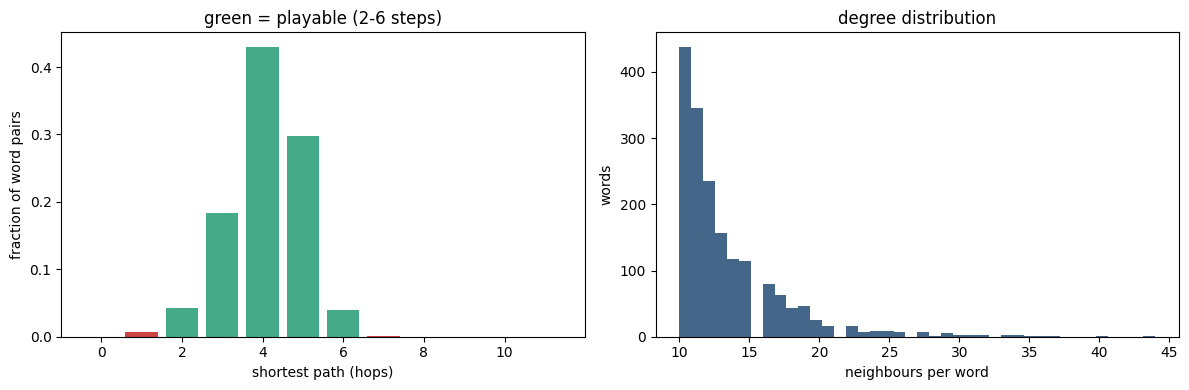

playable  99.2%
1 hop     0.8%  (too close to be a puzzle)
degree    min 10  median 12  max 44


In [5]:
off = D[~np.eye(len(WORDS), dtype=bool)]
reach = off[off != 255]
counts = np.bincount(reach, minlength=12)[:12]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#c44' if (h < 2 or h > 6) else '#4a8' for h in range(12)]
ax[0].bar(range(12), counts / off.size, color=colors)
ax[0].set(xlabel='shortest path (hops)', ylabel='fraction of word pairs',
          title='green = playable (2-6 steps)')

deg = A.sum(1)
ax[1].hist(deg, bins=40, color='#468')
ax[1].set(xlabel='neighbours per word', ylabel='words', title='degree distribution')
plt.tight_layout(); plt.show()

print(f'playable  {np.mean((off >= 2) & (off <= 6)):.1%}')
print(f'1 hop     {np.mean(off == 1):.1%}  (too close to be a puzzle)')
print(f'degree    min {deg.min()}  median {np.median(deg):.0f}  max {deg.max()}')

## hubs

words with runaway degree distort every path that passes through them.

In [6]:
for i in np.argsort(-deg)[:15]:
    print(f'  {WORDS[i]:<18}{deg[i]:>4} neighbours')
print('\nleast connected:')
for i in np.argsort(deg)[:10]:
    print(f'  {WORDS[i]:<18}{deg[i]:>4}')

  document            44 neighbours
  analysis            40 neighbours
  computer            37 neighbours
  sadness             36 neighbours
  device              35 neighbours
  reason              34 neighbours
  music               34 neighbours
  tool                33 neighbours
  run                 33 neighbours
  running             32 neighbours
  thought             32 neighbours
  clothing            31 neighbours
  paper               31 neighbours
  analyze             30 neighbours
  sport               30 neighbours

least connected:
  freezer             10
  predecessor         10
  predict             10
  principle           10
  fresh               10
  enter               10
  compress            10
  productivity        10
  protein             10
  envious             10


## map of the space

umap if installed, otherwise a pca fallback so the cell always runs.

/Users/anushkapunukollu/Six-Degrees-1/backend/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/anushkapunukollu/Six-Degrees-1/backend/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


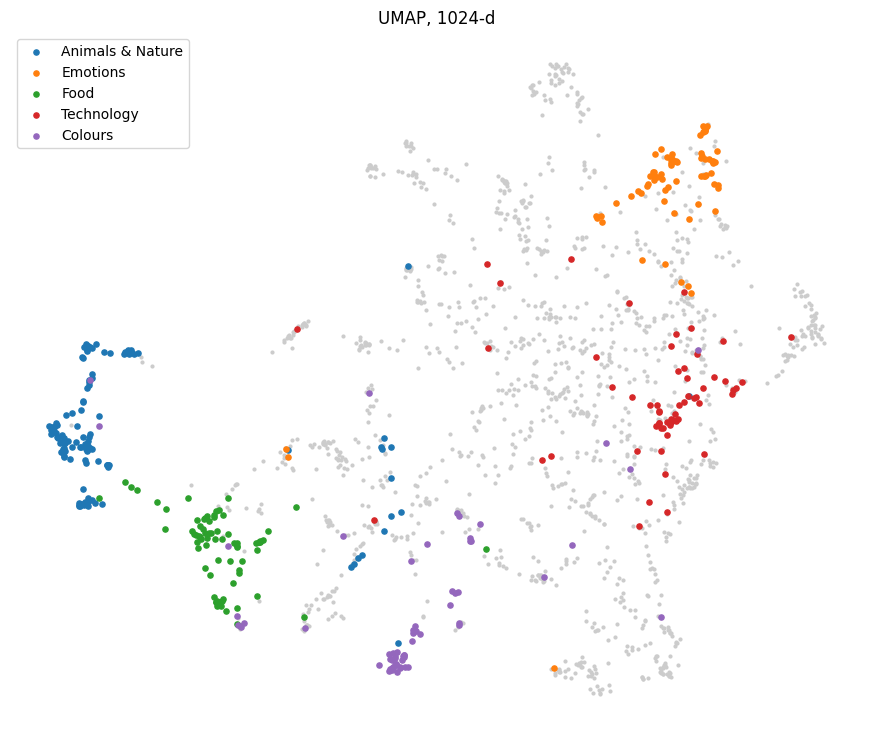

In [7]:
try:
    import umap
    xy = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine',
                   random_state=0).fit_transform(V)
    method = 'UMAP'
except ImportError:
    centered = V - V.mean(0)
    xy = centered @ np.linalg.svd(centered, full_matrices=False)[2][:2].T
    method = 'PCA (pip install umap-learn for UMAP)'

cats = json.loads((ROOT / 'data/words.json').read_text())['categories']
plt.figure(figsize=(11, 9))
plt.scatter(xy[:, 0], xy[:, 1], s=4, c='#ccc')
for name in ['Animals & Nature', 'Emotions', 'Food', 'Technology', 'Colours']:
    pts = np.array([xy[IDX[w]] for w in cats.get(name, []) if w in IDX])
    if len(pts):
        plt.scatter(pts[:, 0], pts[:, 1], s=14, label=name)
plt.legend(); plt.title(f'{method}, {DIM}-d'); plt.axis('off'); plt.show()